# ex014_Xie2015_B1

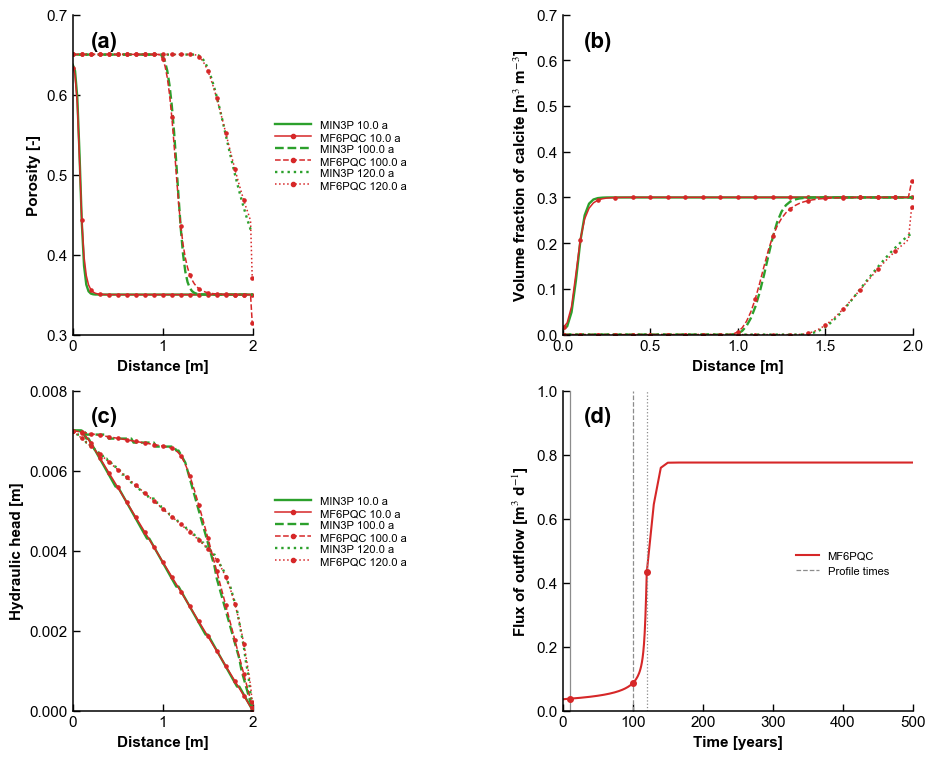

Time (yr),10,100,120
Variable,,,
Porosity,0.00254208,0.0068298,0.00706626
Calcite,0.00300802,0.00713835,0.00703883
Hydraulic head,3.29502e-05,7.35733e-05,5.15649e-05


In [2]:
import pandas as pd
from IPython.display import display

comparison_rows = []
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.dont_write_bytecode = True
CASE_DIR = next(
    p
    for root in (Path.cwd(), *Path.cwd().parents)
    for p in (root, root / "examples/ex014_Xie2015_B1")
    if p.name == "ex014_Xie2015_B1" and (p / "run.py").is_file()
)
sys.path.insert(0, str(CASE_DIR.parent))
from example_utils import load_results, read_headings, runtime_path, time_indices

CASE_FILE = CASE_DIR / "run.py"
INPUT_DIR = CASE_DIR / "input_data"
OUTPUT_DIR = runtime_path(CASE_FILE, "output")
SIMULATION_DIR = runtime_path(CASE_FILE, "simulation")


def load_case_results(output_dir):
    if (output_dir / "results_times.npy").is_file():
        return load_results(output_dir)
    values = np.load(output_dir / "results.npy")
    headings = read_headings(output_dir)
    text = next(SIMULATION_DIR.glob("*.tdis")).read_text().lower()
    periods = np.array(
        [
            [float(v) for v in row.split()]
            for row in text.split("begin perioddata")[1].split("end perioddata")[0].splitlines()
            if row.strip()
        ]
    )
    assert np.all(periods[:, 2] == 1), "Legacy snapshots require uniform steps within each period"
    steps = periods[:, 1].astype(int)
    stride, remainder = divmod(int(steps.sum()), len(values) - 1)
    assert not remainder and stride > 0, "Legacy snapshot count does not match the TDIS schedule"
    times = np.r_[0, np.cumsum(np.repeat(periods[:, 0] / steps, steps))[stride - 1 :: stride]]
    return (values, headings, times)


import flopy

plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 11,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "mathtext.fontset": "stix",
    }
)
REFERENCE_FILE = INPUT_DIR / "MIN3P_results.csv"
PROFILE_YEARS = (10, 100, 120)
SIMULATION_YEARS = 500
SAVE_INTERVAL = 1000
LENGTH = 2.0
INITIAL_CALCITE_VOLUME_FRACTION = 0.3
CALCITE_MOLAR_VOLUME = 0.03693
required = [OUTPUT_DIR / name for name in ("results.npy", "results_porosity.npy", "results_K.npy")]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError("Run run.py before plotting. Missing: " + ", ".join(missing))
results, headings, result_times = load_case_results(OUTPUT_DIR)
porosity = np.load(OUTPUT_DIR / "results_porosity.npy", mmap_mode="r")
permeability = np.load(OUTPUT_DIR / "results_K.npy", mmap_mode="r")
reference = pd.read_csv(REFERENCE_FILE)
sim = flopy.mf6.MFSimulation.load(sim_ws=str(SIMULATION_DIR), sim_name="model", verbosity_level=0)
years = result_times / 365.0
if len(years) != porosity.shape[0]:
    raise ValueError("The saved porosity history does not match the TDIS time grid.")
if years[-1] < max(PROFILE_YEARS):
    raise ValueError(f"Results end at {years[-1]:.1f} years; B1 needs at least 120 years.")
head_file = flopy.utils.HeadFile(str(SIMULATION_DIR / "gwf_model.hds"))
delr_mf6 = sim.get_model("gwf_model").dis.delr.array.ravel()
x_mf6 = np.cumsum(delr_mf6) - 0.5 * delr_mf6
x_min3p = np.linspace(0.0, LENGTH, len(reference))
head_times = np.asarray(head_file.get_times()) / 365.0
head_kstpkper = head_file.get_kstpkper()


def nearest_index(values, target):
    return int(np.abs(np.asarray(values) - target).argmin())


def profile_at_year(array, year, *, has_initial_state=False):
    index = nearest_index(years, year)
    if not np.isclose(years[index], year):
        raise ValueError(f"No saved result for {year} years.")
    return array[index if has_initial_state else index - 1]


head_profiles = {
    year: head_file.get_data(kstpkper=head_kstpkper[nearest_index(head_times, year)])[0, 0]
    for year in PROFILE_YEARS
}
calcite_index = headings.index("Calcite")


def calcite_profile_at_year(year):
    index = int(time_indices(years, [year])[0])
    return results[index, calcite_index] * CALCITE_MOLAR_VOLUME


for year in PROFILE_YEARS:
    profiles = {
        "Porosity": porosity[nearest_index(years, year)],
        "Calcite": calcite_profile_at_year(year),
        "Hydraulic head": head_profiles[year],
    }
    for name, values in profiles.items():
        error = np.interp(x_min3p, x_mf6, values) - reference[f"{name} {year}years"]
        comparison_rows.append(
            {"Variable": name, "Time (yr)": year, "RMSE": np.sqrt(np.mean(error**2))}
        )
gwf = sim.get_model("gwf_model")
right_ghb = gwf.get_package("ghb_right")
right_spd = right_ghb.stress_period_data.get_data(key=0)
right_boundary_head = float(right_spd["bhead"][0])
right_boundary_distance = 0.5 * delr_mf6[-1]
saved_head_right = np.array(
    [
        head_file.get_data(kstpkper=head_kstpkper[nearest_index(head_times, year)])[0, 0, -1]
        for year in years
    ]
)
saved_outflow_flux = (
    permeability[:, -1] * (saved_head_right - right_boundary_head) / right_boundary_distance
)
saved_outflow_flux[0] = permeability[0, -1] * 0.007 / LENGTH
flux_years = np.arange(SIMULATION_YEARS + 1, dtype=float)
outflow_flux = np.interp(flux_years, years, saved_outflow_flux)
profile_flux = {year: saved_outflow_flux[nearest_index(years, year)] for year in PROFILE_YEARS}
styles = {10: "-", 100: "--", 120: ":"}
fig = plt.figure(figsize=(10.0, 8.0), facecolor="white")
axes = np.array(
    [
        [fig.add_axes((0.09, 0.55, 0.18, 0.4)), fig.add_axes((0.58, 0.55, 0.35, 0.4))],
        [fig.add_axes((0.09, 0.08, 0.18, 0.4)), fig.add_axes((0.58, 0.08, 0.35, 0.4))],
    ]
)
ax = axes[0, 0]
for year, style in styles.items():
    ax.plot(x_min3p, reference[f"Porosity {year}years"], color="tab:green", ls=style, lw=1.7)
    ax.plot(
        x_mf6,
        profile_at_year(porosity, year, has_initial_state=True),
        color="tab:red",
        ls=style,
        lw=1.1,
        marker="o",
        ms=2.3,
        markevery=4,
    )
ax.set(xlim=(0, LENGTH), ylim=(0.3, 0.7), xlabel="Distance [m]", ylabel="Porosity [-]")
ax.set_yticks(np.arange(0.3, 0.71, 0.1))
ax.text(0.1, 0.95, "(a)", transform=ax.transAxes, va="top", fontsize=16, fontweight="bold")
ax = axes[0, 1]
for year, style in styles.items():
    ax.plot(x_min3p, reference[f"Calcite {year}years"], color="tab:green", ls=style, lw=1.7)
    ax.plot(
        x_mf6,
        calcite_profile_at_year(year),
        color="tab:red",
        ls=style,
        lw=1.1,
        marker="o",
        ms=2.3,
        markevery=4,
    )
ax.set(
    xlim=(0, LENGTH),
    ylim=(0, 0.7),
    xlabel="Distance [m]",
    ylabel="Volume fraction of calcite [m$^3$ m$^{-3}$]",
)
ax.set_yticks(np.arange(0.0, 0.71, 0.1))
ax.text(0.06, 0.95, "(b)", transform=ax.transAxes, va="top", fontsize=16, fontweight="bold")
ax = axes[1, 0]
for year, style in styles.items():
    ax.plot(x_min3p, reference[f"Hydraulic head {year}years"], color="tab:green", ls=style, lw=1.7)
    ax.plot(
        x_mf6,
        head_profiles[year],
        color="tab:red",
        ls=style,
        lw=1.1,
        marker="o",
        ms=2.3,
        markevery=4,
    )
ax.set(xlim=(0, LENGTH), ylim=(0, 0.008), xlabel="Distance [m]", ylabel="Hydraulic head [m]")
ax.set_yticks(np.arange(0.0, 0.0081, 0.002))
ax.text(0.1, 0.95, "(c)", transform=ax.transAxes, va="top", fontsize=16, fontweight="bold")
ax = axes[1, 1]
ax.plot(flux_years, outflow_flux, color="tab:red", lw=1.5, label="MF6PQC")
for year, style in styles.items():
    ax.axvline(year, color="0.55", ls=style, lw=0.9)
    if year in profile_flux:
        ax.plot(year, profile_flux[year], "o", color="tab:red", ms=4)
ax.set(
    xlim=(0, SIMULATION_YEARS),
    ylim=(0, 1.0),
    xlabel="Time [years]",
    ylabel="Flux of outflow [m$^3$ d$^{-1}$]",
)
ax.set_yticks(np.arange(0.0, 1.01, 0.2))
ax.text(0.06, 0.95, "(d)", transform=ax.transAxes, va="top", fontsize=16, fontweight="bold")
for ax in axes.flat:
    ax.tick_params(direction="in", length=5, width=1.0, top=False, right=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)
    ax.xaxis.label.set_fontweight("bold")
    ax.yaxis.label.set_fontweight("bold")
from matplotlib.lines import Line2D

legend_handles = [
    item
    for year, style in styles.items()
    for item in (
        Line2D([], [], color="tab:green", ls=style, lw=1.7, label=f"MIN3P {year:.1f} a"),
        Line2D(
            [],
            [],
            color="tab:red",
            ls=style,
            marker="o",
            lw=1.1,
            ms=3,
            label=f"MF6PQC {year:.1f} a",
        ),
    )
]
for ax in (axes[0, 0], axes[1, 0]):
    ax.legend(
        handles=legend_handles,
        frameon=False,
        fontsize=8,
        handlelength=3.2,
        loc="center left",
        bbox_to_anchor=(1.1, 0.56),
        borderaxespad=0.0,
        labelspacing=0.18,
    )
axes[1, 1].legend(
    handles=[
        Line2D([], [], color="tab:red", lw=1.5, label="MF6PQC"),
        Line2D([], [], color="0.55", ls="--", lw=0.9, label="Profile times"),
    ],
    frameon=False,
    fontsize=8,
    loc="center right",
    bbox_to_anchor=(0.96, 0.46),
)
plt.show()
comparison = pd.DataFrame(comparison_rows)
comparison = comparison.pivot(index="Variable", columns="Time (yr)", values="RMSE").reindex(
    comparison["Variable"].drop_duplicates()
)
display(comparison.style.format("{:.6g}").format_index("{:.6g}", axis=1).set_uuid("ex014_1"))